## Simple test of `POPSRegression`

Usage is very similar to BayesianRidge

In [1]:
from sklearn.linear_model import BayesianRidge

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from POPSRegression import POPSRegression

In [20]:
def fit_models(N,density=1.0,posterior='hypercube'):
    f = lambda x: (x**3+ 0.01* x**4)*0.1 + np.sin(x)*x*10. 
    x_train = np.append(np.random.uniform(-1, 1, N),np.linspace(-1,1,2)) * 10
    x_train = np.sort(x_train)
    
    x_dense = np.linspace(-1.1,1.1,51)* 10
    y_dense = f(x_dense)

    p = PolynomialFeatures(degree=4, include_bias=True)
    X_train = p.fit_transform(x_train.reshape(-1,1))
    X_dense = p.fit_transform(x_dense.reshape(-1,1))
    y_train = f(x_train)

    m = POPSRegression(resampling_method='uniform',leverage_percentile=0.0,resample_density=10.,posterior=posterior)
    m.fit(X_train,y_train)

    y_pred,y_std,y_max,y_min = m.predict(X_dense,return_std=True,return_bounds=True)

    b = BayesianRidge(fit_intercept=False)
    b.fit(X_train,y_train)
    
    # extract mean and epistemic uncertainty (no aleatoric!)
    b_pred = b.predict(X_dense,return_std=False)
    b_std = np.sqrt(np.sum(np.dot(X_dense,b.sigma_)*X_dense,axis=1))
    
    return X_dense.shape[1],x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max,y_min,b_pred,b_std,m

def plot_panel(ax,x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max,y_min,b_pred,b_std,model):
    ax.fill_between(x_dense,y_min,y_max,alpha=0.2,facecolor='0.5',label='POPS max/min')
    
    ax.fill_between(x_dense,y_pred-2*y_std,y_pred+2*y_std,alpha=0.5,facecolor='C1',label=r'POPS $\pm2\sigma$')
    ax.plot(x_dense,y_pred,'C1-',lw=4)

    ax.fill_between(x_dense,b_pred-2*b_std,b_pred+2*b_std,alpha=0.5,facecolor='C2',label=r'BayesianRidge  $\pm2\sigma$')
    ax.plot(x_dense,b_pred,'C2-',lw=2)
    ax.plot(x_train,y_train,'b.',label='Train')
    ax.plot(x_dense,y_dense,'k-',label='Truth')

def generate_data(N):
    f = lambda x: (x**3+ 0.01* x**4)*0.1 + np.sin(x)*x*10. 
    x_train = np.append(np.random.uniform(-1, 1, N),np.linspace(-1,1,2)) * 10
    x_train = np.sort(x_train)
    
    x_dense = np.linspace(-1.1,1.1,51)* 10
    y_dense = f(x_dense)

    p = PolynomialFeatures(degree=4, include_bias=True)
    X_train = p.fit_transform(x_train.reshape(-1,1))
    X_dense = p.fit_transform(x_dense.reshape(-1,1))
    y_train = f(x_train)
    return X_train,x_train,y_train,X_dense,x_dense,y_dense

def plot_panel(ax,x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max=None,y_min=None,label='POPS'):
    if y_max is not None and y_min is not None:
        ax.fill_between(x_dense,y_min,y_max,alpha=0.2,facecolor='0.5',label=f'max/min')
    else:
        ax.fill_between(x_dense,y_pred-4*y_std,y_pred+4*y_std,alpha=0.2,facecolor='0.5',label=r'$\pm4\sigma$')
    
    ax.fill_between(x_dense,y_pred-2*y_std,y_pred+2*y_std,alpha=0.5,facecolor='C1',label=r'$\pm2\sigma$')
    ax.plot(x_dense,y_pred,'C1-',lw=4)
    ax.plot(x_train,y_train,'b.',label='Train')
    ax.plot(x_dense,y_dense,'k-')#,label='Truth')
    






In [21]:
class CustomBayesianRidge(BayesianRidge):
    def predict(self,X,return_std=True,return_bounds=True):
        y_mean = super().predict(X,return_std=False)
        res_dict = {'y_mean':y_mean,'y_std':None,'y_min':None,'y_max':None}
        if return_std:
            res_dict['y_std'] = np.sqrt(np.sum(np.dot(X_dense,self.sigma_)*X_dense,axis=1))
        return tuple(v for v in res_dict.values())

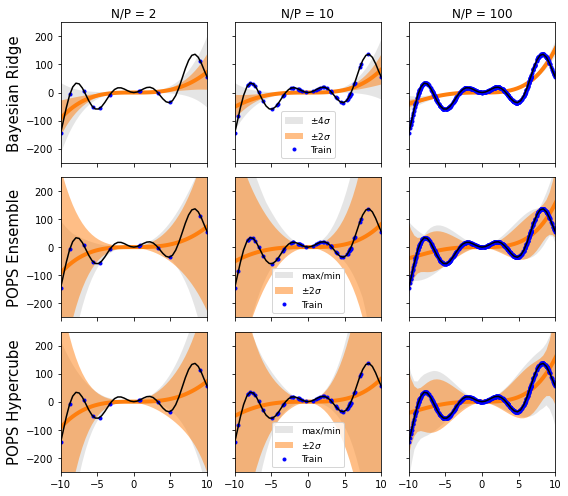

In [28]:
titles = ['Bayesian Ridge','POPS Ensemble','POPS Hypercube']
fig,axs = plt.subplots(3,3,figsize=(8,7),dpi=72,sharex=True,sharey=True)
N_array = [10,50,500]
P = 5
for i,N in enumerate(N_array):
    X_train,x_train,y_train,X_dense,x_dense,y_dense = generate_data(N)
    ens = POPSRegression(leverage_percentile=0.0,posterior='ensemble')
    hyc = POPSRegression(leverage_percentile=0.0,posterior='hypercube')
    bay = CustomBayesianRidge(fit_intercept=False)
    
    ens.fit(X_train,y_train)
    hyc.fit(X_train,y_train)
    bay.fit(X_train,y_train)
    
    y_pred,y_std,y_min,y_max = bay.predict(X_dense)
    plot_panel(axs[0,i],x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max=None,y_min=None,label=titles[0])

    y_pred,y_std,y_min,y_max = ens.predict(X_dense,return_std=True,return_bounds=True)
    plot_panel(axs[1,i],x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max=y_max,y_min=y_min,label=titles[1])

    y_pred,y_std,y_min,y_max = hyc.predict(X_dense,return_std=True,return_bounds=True)
    plot_panel(axs[2,i],x_dense,y_dense,x_train,y_train,y_pred,y_std,y_max=y_max,y_min=y_min,label=titles[2])
    axs[0,i].set_title(f"N/P = {N//P}")

for j,title in enumerate(titles):
    axs[j,0].set_ylim(-250,250)
    axs[j,0].set_xlim(-10,10)
    axs[j,1].legend(fontsize=9,loc='lower center')
    axs[j,0].set_ylabel(title,fontsize=15)
plt.tight_layout()
plt.savefig("example_image.png");